### Import packages

In [9]:
#Import general libs you'll need
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Import functions from main
from main import ATL_AGG_CONFIG

# Import functions from the utils
from utils import readers, analysis, processing
from utils import plotter
from utils.create_las_swath import create_als_swath, transform_als_swath
from utils.datum_transforms import convert_3d_nad83_to_wgs84
from utils.datum_transforms import get_geoid_height



### Identify files



In [2]:
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl03_name = 'ATL03_20250616013703_00052802_007_01.h5'
atl03_name = 'ATL03_20181215070448_11860106_007_01.h5'
atl03_file = os.path.join(atl03_dir, atl03_name)

# Define ATL08 File /home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl08_name = 'ATL08_20250616013703_00052802_007_01.h5'
atl08_name = 'ATL08_20181215070448_11860106_007_01.h5'
atl08_file = os.path.join(atl08_dir, atl08_name)

# Define the ground track of interest
gt = 'gt2l'

# Identify ATX AOI
extent_file = '/home/ejg2736/dev/icesat2_topobathy/data/austin_laz_bigtex.gpkg'

# ALS Geoid File
als_geoid_file = '/home/ejg2736/dev/geoid/agisoft/us_noaa_g2018u0.tif'

### Get photon rate dataframe


In [3]:
# Get photon rate DF
df_ph = readers.read_photon_dataframe(atl03_file, gt, atl08_file)


In [4]:
# Filter df_ph
extent_gdf = gpd.read_file(extent_file)
df_ph = processing.filter_df_by_extent(df_ph, extent_gdf.total_bounds)


### Plot output 

Check to make sure it plots correctly

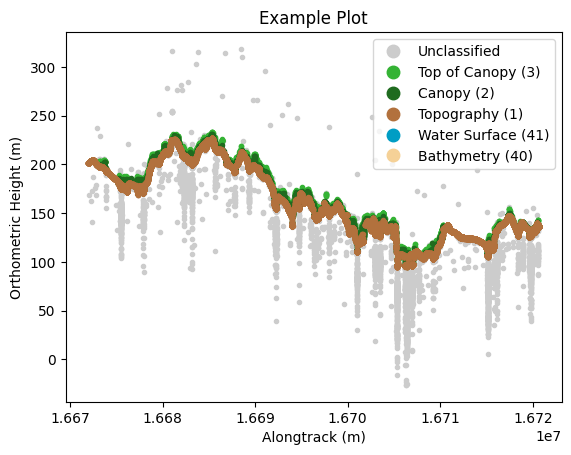

In [5]:
import matplotlib.pyplot as plt
plotter.plot_alongtrack(df_ph.alongtrack, df_ph.h_ph, df_ph.atl08_class,'Example Plot')

### Process ALS Swath

Load the ALS Swath and preprocess it 

In [19]:
os.path.basename(atl03_name).split('.h5')[0]

'ATL03_20181215070448_11860106_007_01'

In [ ]:
# Load swath if available
als_outdir = '/home/ejg2736/dev/icesat2_topobathy/als_swaths'
file_out_name = f"{os.path.basename(atl03_name).split('.h5')[0]}_{gt}"
als_outfile = os.path.join(als_outdir, f'als_{file_out_name}.pqt')                
if os.path.exists(als_outfile):
    als_swath = pd.read_parquet(als_outfile)
else:
    als_swath = create_als_swath(extent_gdf, df_ph)
    als_swath = transform_als_swath(als_swath, 
        'EPSG:32614', 
        source_geoid_file=als_geoid_file,
        target_geoid_file=None, 
        input_units='meters', 
        source_datum='nad83'
    )
    als_swath.to_parquet(als_outfile)

Processing [4 workers]


Processing Tiles::   0%|          | 0/27 [00:00<?, ?it/s]

In [13]:
file_out_name

'ATL03_20181215070448_11860106_007_01.h5_gt2l'

In [15]:
als_swath

,x,y,z,classification,crosstrack,alongtrack,file,t_ind,h_norm,latitude,longitude
0,629696.687361,3.369771e+06,801.53,2,-24.521576,1.668414e+07,stratmap21-28cm_3097352d3.laz,5225,4.80,30.453120,-97.649146
1,629696.445609,3.369772e+06,801.57,2,-24.776821,1.668414e+07,stratmap21-28cm_3097352d3.laz,5225,4.84,30.453121,-97.649148
2,629697.392245,3.369771e+06,801.43,2,-23.803853,1.668414e+07,stratmap21-28cm_3097352d3.laz,5225,4.70,30.453118,-97.649139
3,629697.617899,3.369772e+06,801.46,2,-23.600819,1.668414e+07,stratmap21-28cm_3097352d3.laz,5225,4.73,30.453120,-97.649136
4,629699.298171,3.369772e+06,801.30,2,-21.953755,1.668414e+07,stratmap21-28cm_3097352d3.laz,5225,4.57,30.453123,-97.649119
...,...,...,...,...,...,...,...,...,...,...,...
6170381,626928.058461,3.336833e+06,560.47,2,18.252129,1.671720e+07,stratmap21-28cm_3097514a3.laz,38286,-2.08,30.156251,-97.681958
6170382,626927.589476,3.336833e+06,560.60,2,17.761527,1.671720e+07,stratmap21-28cm_3097514a3.laz,38286,-1.95,30.156254,-97.681963
6170383,626927.078703,3.336833e+06,560.65,2,17.285837,1.671720e+07,stratmap21-28cm_3097514a3.laz,38286,-1.90,30.156250,-97.681968
6170384,626931.369286,3.336833e+06,560.43,2,21.543905,1.671720e+07,stratmap21-28cm_3097514a3.laz,38286,-2.12,30.156252,-97.681924


In [ ]:
# Transform ALS swath if it hasn't been transformed yet (e.g. if loaded from an older untransformed parquet file)
# if 'latitude' not in als_swath.columns and len(als_swath) > 0:
als_swath = transform_als_swath(als_swath, 
    'EPSG:32614', 
    source_geoid_file=als_geoid_file,
    target_geoid_file=None, 
    input_units='meters', 
    source_datum='nad83'
)
als_swath.to_parquet(als_outfile)





IndexError: index 23541 is out of bounds for axis 1 with size 4201

In [ ]:
extent_gdf.parse_crs.iloc[0]

'COMPD_CS["NAD83(2011) / Texas Central (ftUS) + NAVD88 height - Geoid18 (ftUS)",PROJCS["NAD83(2011) / Texas Central (ftUS)",GEOGCS["NAD83(2011)",DATUM["NAD83 (National_Spatial_Reference_System_2011)",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["Degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["Standard_Parallel_1",31.88333333333333],PARAMETER["Standard_Parallel_2",30.11666666666667],PARAMETER["Latitude_Of_Origin",29.66666666666667],PARAMETER["Central_Meridian",-100.3333333333333],PARAMETER["False_Easting",2296583.333],PARAMETER["False_Northing",9842500.000000002],UNIT["US survey foot",0.3048006096012192,AUTHORITY["EPSG","9003"]],AXIS["X",EAST],AXIS["Y",NORTH],AUTHORITY["EPSG","6578"]],VERT_CS["NAVD88 height - Geoid18 (ftUS)",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UN

In [ ]:
als_swath2 = generate_and_process_als_swath(
    extent_gdf, 
    df_ph, 
    'EPSG:32617', 
    source_geoid_file=als_geoid_file,
    target_geoid_file=None, 
    input_units='meters', 
    source_datum='nad83'
)
als_swath.to_parquet(als_outfile)

In [ ]:
# Convert ALS Swath from feet to meters
als_swath.z = als_swath.z * 0.3048

#

epsg_code = int(str(utm_epsg).split(':')[-1])
transformer = Transformer.from_crs(epsg_code, 4326, always_xy=True)

als_lon, als_lat = transformer.transform(als_swath.x.values, als_swath.y.values)
als_swath['latitude'] = als_lat
als_swath['longitude'] = als_lon

# Convert ALS Swath from Orthometric to Ellipsoidal

transformer = Transformer.from_crs(int(utm_epsg[5:]),4326)
als_lat, als_lon  =transformer.transform(als_swath.x, als_swath.y)
geoid_offset = get_geoid_height(als_lon + 360, als_lat, als_geoid_file)
als_swath['ellip_h'] = als_swath.z + geoid_offset
als_swath['latitude'] = als_lat
als_swath['longitude'] = als_lon

# Convert NAD83 to WGS84
_,_,als_swath.ellip_h = convert_3d_nad83_to_wgs84(als_lon, als_lat, als_swath.ellip_h)


NameError: name 'Transformer' is not defined

In [76]:
als_swath.columns

Index(['x', 'y', 'z', 'classification', 'crosstrack', 'alongtrack', 'file'], dtype='object')

In [ ]:
def plot_alongtrack_atl_als3(df_ph, df_als,title):
    plt.figure()
    # plt.plot(df_als.alongtrack[df_als.classification == 7],df_als.ortho_h[df_als.classification == 7],'.',color=[0.8,0,0],label='Noise (7)')
    plt.plot(df_als.alongtrack[df_als.classification.isin([41,45])],df_als.z[df_als.classification.isin([41,45])],'.',color=[0.4, 0.4, 0.6],label='ALS Water')
    plt.plot(df_als.alongtrack[df_als.classification.isin([1,3,4,5])],df_als.z[df_als.classification.isin([1,3,4,5])],'.',color=[0.7, 0.9, 0.7],label='ALS Unclassified (Veg)')
    plt.plot(df_als.alongtrack[df_als.classification.isin([2,40])],df_als.z[df_als.classification.isin([2,40])],'.',color=[0.4, 0.4, 0.4],label='ALS Topobathy')
    
    plt.plot(df_ph.alongtrack[df_ph.atl08_class == 0],df_ph.h_ph[df_ph.atl08_class == 0],'.',color=[0.8,0.8,0.8],label='Unclassified')
    # plt.plot(df_ph.alongtrack[df_ph.combined_class == 3],df_ph.ortho_h[df_ph.combined_class == 3],'.',color=[0.20392157, 0.70196078, 0.20392157],label='Top of Canopy (3)')
    plt.plot(df_ph.alongtrack[df_ph.atl08_class.isin([2,3])],df_ph.h_ph[df_ph.atl08_class.isin([2,3])],'.',color=[0.12156863, 0.41960784, 0.12156863],label='ATL08 Canopy')
    plt.plot(df_ph.alongtrack[df_ph.atl08_class == 1],df_ph.h_ph[df_ph.atl08_class == 1],'.',color=[0.69803922, 0.44313725, 0.23921569],label='ATL08 Terrain')
    plt.plot(df_ph.alongtrack[df_ph.atl08_class == 41],df_ph.h_ph[df_ph.atl08_class == 41],'.',color=[0.        , 0.61568627, 0.76862745],label='ATL24 Water Surface')
    plt.plot(df_ph.alongtrack[df_ph.atl08_class == 40],df_ph.h_ph[df_ph.atl08_class == 40],'.',color=[0.96078431, 0.81960784, 0.59215686],label='ATL24 Bathymetry')
    plt.xlabel('Alongtrack (m)')
    plt.ylabel('Orthometric Height (m)')
    plt.legend(markerscale=3)
    plt.title(title)
    plt.show()

/home/ejg2736/miniconda3/envs/spyder_pr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


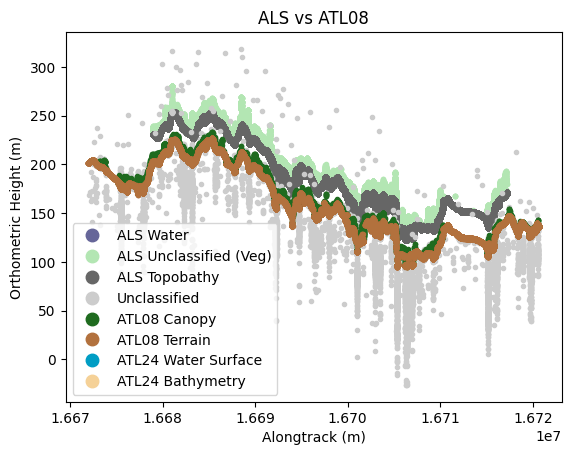

In [ ]:
plot_alongtrack_atl_als3(df_ph, als_swath,'ALS vs ATL08')

### Write out the data

Write out the data as a geopandas dataframe if needed

In [6]:
# Write out as geopandas dataframe
geometry_seg = [Point(xy) for xy in zip(df_seg.longitude, df_seg.latitude)]
gdf_seg = gpd.GeoDataFrame(df_seg, geometry=geometry_seg, crs="EPSG:4326")

# Save geopandas dataframe
gdf_seg.to_file("is2_topobathy.gpkg", layer='atl08atl24', driver="GPKG")